# PU experiments

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_experiment import load_experiment_results 
import datetime 
from helpers import get_n_labels


In [23]:
EXPERIMENT = "c"

In [24]:
df = load_experiment_results(name=EXPERIMENT,n=0)
df = df[df["model"]!="oracle"]
df

,c,dataset,iter,model,accuracy,0 precision,1 precision,0 recall,1 recall,0 f1,1 f1,0 support,1 support,calculated_c,feature
0,0.05,breastcancer,0,classic,0.371681,0.371681,0.000000,1.000000,0.000000,0.541935,0.000000,42,71,0.048951,--scar--
1,0.05,breastcancer,0,naive,0.929204,0.972222,0.909091,0.833333,0.985915,0.897436,0.945946,42,71,0.048951,--scar--
3,0.05,breastcancer,0,two_model,0.743363,0.591549,1.000000,1.000000,0.591549,0.743363,0.743363,42,71,0.048951,--scar--
4,0.05,breastcancer,1,classic,0.371681,0.371681,0.000000,1.000000,0.000000,0.541935,0.000000,42,71,0.048951,--scar--
5,0.05,breastcancer,1,naive,0.876106,0.937500,0.851852,0.714286,0.971831,0.810811,0.907895,42,71,0.048951,--scar--
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373,0.95,breastcancer,3,naive,0.982301,0.954545,1.000000,1.000000,0.971831,0.976744,0.985714,42,71,0.951049,--scar--
375,0.95,breastcancer,3,two_model,0.955752,0.911111,0.985294,0.976190,0.943662,0.942529,0.964029,42,71,0.951049,--scar--
376,0.95,breastcancer,4,classic,0.973451,0.975610,0.972222,0.952381,0.985915,0.963855,0.979021,42,71,0.951049,--scar--
377,0.95,breastcancer,4,naive,0.973451,0.975610,0.972222,0.952381,0.985915,0.963855,0.979021,42,71,0.951049,--scar--


In [25]:
def remove_failed_experiments(df):
    """Remove failed experiments from the dataframe."""
    idx = df.loc[(df["0 precision"]==0) | (df["0 recall"]==0) | (df["1 precision"]==0) | (df["1 recall"]==0)].index
    return df.drop(index=idx)

print("Before removing failed experiments:", df.shape)
# df = remove_failed_experiments(df)
print("After removing failed experiments:", df.shape)


Before removing failed experiments: (285, 15)
After removing failed experiments: (285, 15)


In [26]:
# df["precision"] = (df["0 precision"]+df["1 precision"]) / 2
# df["recall"] = (df["0 recall"]+df["1 recall"]) / 2
# df["f1"] = (df["0 f1"]+df["1 f1"]) / 2

df["f1"] = df["1 f1"]
df["precision"] = df["1 precision"]
df["recall"] = df["1 recall"]

df[["precision","recall","f1"]] = df[["precision","recall","f1"]].round(4) # rounding to 4 decimals
df[["precision","recall","f1"]].describe()

,precision,recall,f1
count,285.000000,285.000000,285.000000
mean,0.916023,0.732242,0.780067
std,0.252892,0.322822,0.318739
min,0.000000,0.000000,0.000000
25%,0.972200,0.704200,0.822600
50%,0.985500,0.873200,0.925400
75%,1.000000,0.943700,0.963500
max,1.000000,1.000000,0.993000


In [27]:
fig_experiment_folder = os.path.join("output", EXPERIMENT)
os.makedirs(fig_experiment_folder, exist_ok=True)
current_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
fig_folder = os.path.join(fig_experiment_folder, f"{current_time}")
os.makedirs(fig_folder, exist_ok=True)

In [28]:
df.model.unique()

array(['classic', 'naive', 'two_model'], dtype=object)

In [29]:
df["model"].rename({"two_model":"Two Model","naive":"Naive","classic":"Classic"},inplace=True)

In [30]:
df["c"].unique().tolist()

[0.05,
 0.1,
 0.15000000000000002,
 0.2,
 0.25,
 0.3,
 0.35000000000000003,
 0.4,
 0.45,
 0.5,
 0.55,
 0.6000000000000001,
 0.6500000000000001,
 0.7000000000000001,
 0.7500000000000001,
 0.8,
 0.8500000000000001,
 0.9000000000000001,
 0.9500000000000001]

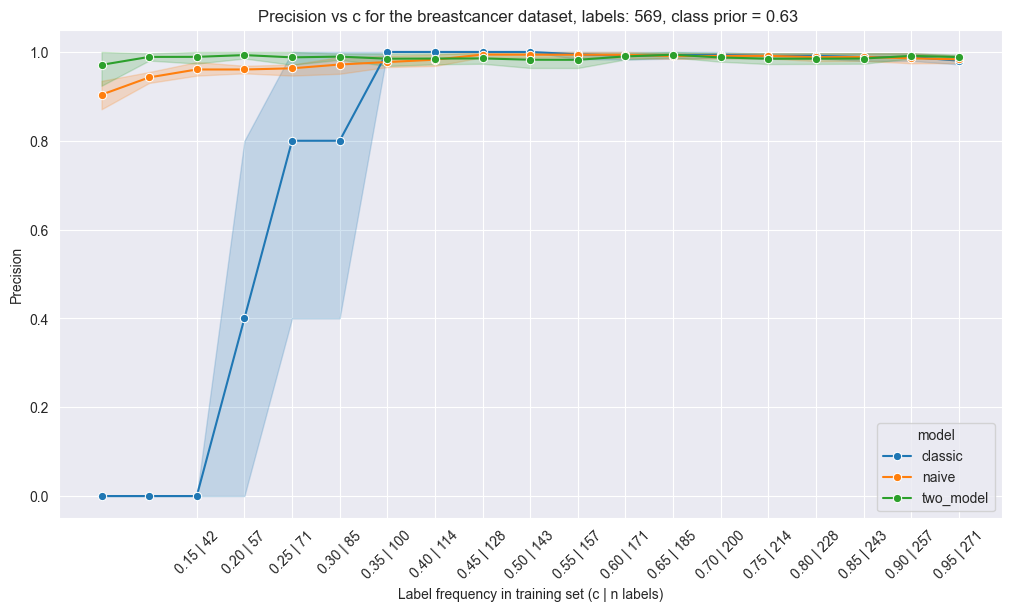

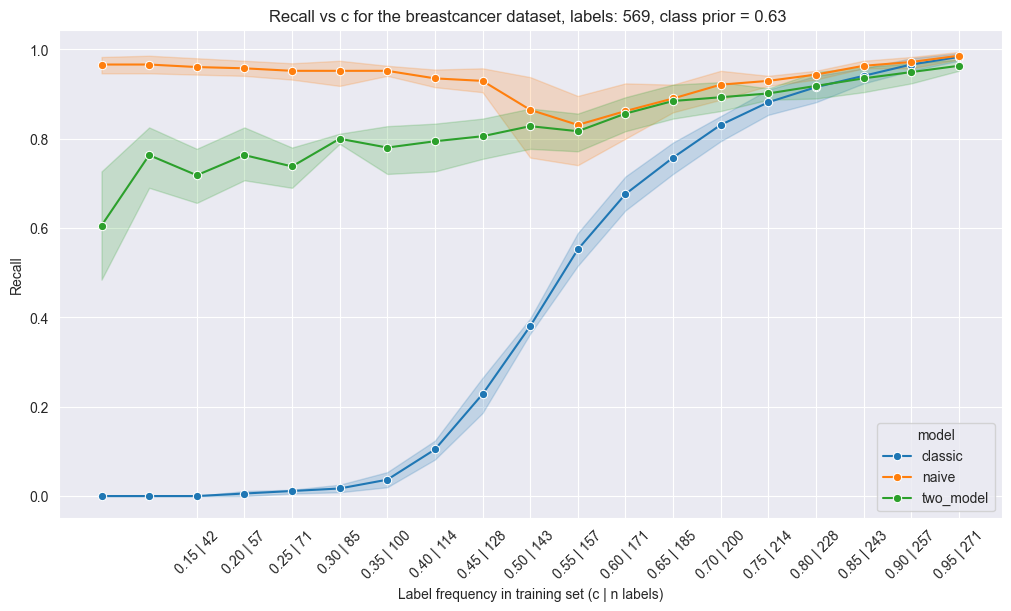

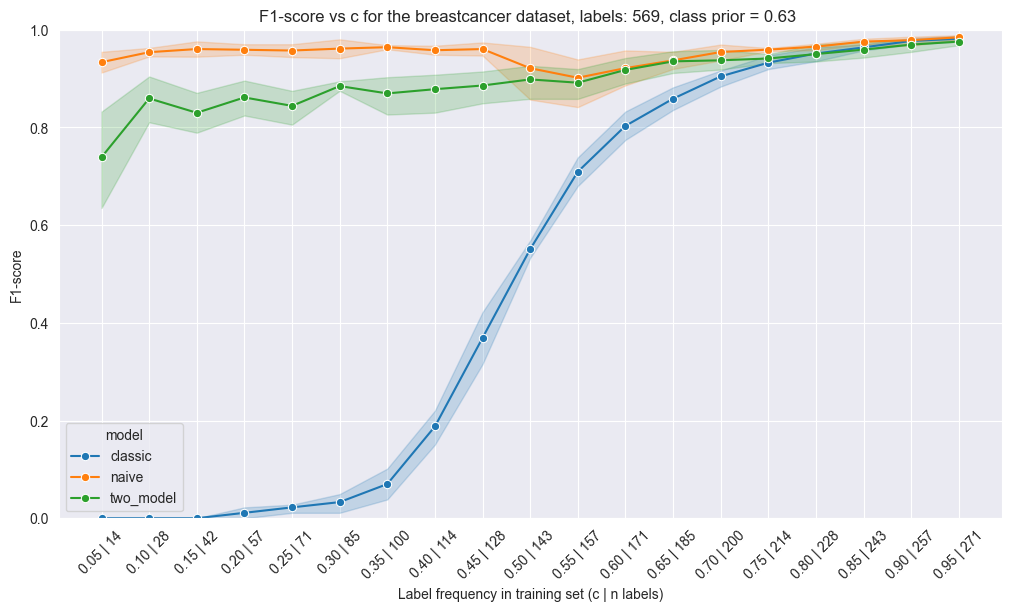

In [31]:
for dataset in df["dataset"].unique():
    assert dataset in ["mock","diabetes","breastcancer","mnist"], (f"Unknown dataset: {dataset}"
                                                                   f"")
    c = df["c"].unique().tolist()
    n_labels = get_n_labels(df, dataset, df["c"].unique())
    ticks = [n_labels[val] for val in c]
    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="precision",marker="o",hue="model",palette={"classic":"C0","naive":"C1","two_model":"C2"})
    plt.title(f"Precision vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Precision")
    plt.xticks(c[2:], ticks[2:],rotation=45)

    plt.xlabel("Label frequency in training set (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"Precision_{dataset}.png"))
    plt.show()

    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="recall",marker="o",hue="model",palette={"classic":"C0","naive":"C1","two_model":"C2"})
    plt.title(f"Recall vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("Recall")
    plt.xticks(c[2:], ticks[2:],rotation=45)
    plt.xlabel("Label frequency in training set (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"Recall_{dataset}.png"))
    plt.show()

    plt.figure(figsize=(10, 6),layout='constrained')
    sns.lineplot(data=df[df["dataset"]==dataset], x="c",y="f1",marker="o",hue="model",palette={"classic":"C0","naive":"C1","two_model":"C2"})
    plt.title(f"F1-score vs c for the {dataset} dataset, {n_labels['title']} ")
    plt.ylabel("F1-score")
    plt.xticks(c, ticks,rotation=45)
    plt.ylim(0, 1)
    plt.xlabel("Label frequency in training set (c | n labels)")
    plt.savefig(os.path.join(fig_folder,f"F1_1_{dataset}.png"))
    plt.show()
